In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Observations

- The second training dataset is just the first dataset + 60 additional images more aligned with the test set.

- The timestamps in the training data are not uniformly spaced, the mode of the time differences between consecutive timestamps from a single camera is around 5-6 seconds, but there are also many timestamps that are 1 minute or more apart. The test data has a different distribution of timestamp differences, with a higher percentage of timestamps that are 1 minute or more apart.
- The training data and test data are recoded on completely different days, probably with a gap of around one month.

- Between cameras, there is not or very little overlap in the timestamps, which means the images from different cameras are not taken at the same time. NO SYNCHRONIZATION BETWEEN CAMERAS.

- There are roughly 5-10 animals in each image, in different postures.

In [1]:
import pandas as pd
import datetime
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

## Load data

In [2]:
data_folder = "/media/cheeko/6E92406092402EC1/Abhilash/multiview_pig_posture_recognition/"
training_data_folders = [f"{data_folder}/train1_images/", f"{data_folder}/train2_images/"]
test_data_folder = f"{data_folder}/test_images/"

train_label_files = [f"{data_folder}/train1.csv", f"{data_folder}/train2.csv"]
test_label_file = f"{data_folder}/test.csv"

In [ ]:
train_label_dfs = [pd.read_csv(train_label_files[i]) for i in range(len(train_label_files))]

# It does not make sense to cobine the training datasets because the second dataset is just the first dataset + 60 additional images more aligned with the test set. 
# combined_train_label_df = pd.concat(train_label_dfs, ignore_index=True)

test_label_df = pd.read_csv(test_label_file)

In [4]:
train_label_dfs[0].head(10)

,row_id,image_id,width,height,bbox,class_id
0,train_pen1_orb_cam1_20250108_085204_0000,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[1031.5,368.0,349.0,435.0]",0
1,train_pen1_orb_cam1_20250108_085204_0001,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[1278.5,428.0,233.0,438.0]",4
2,train_pen1_orb_cam1_20250108_085204_0002,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[732.0,137.5,342.0,198.0]",1
3,train_pen1_orb_cam1_20250108_085204_0003,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[830.0,169.0,370.0,263.0]",0
4,train_pen1_orb_cam1_20250108_085204_0004,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[611.5,314.8,381.5,386.6]",3
5,train_pen1_orb_cam1_20250108_085204_0005,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[1023.4,261.6,340.6,192.4]",4
6,train_pen1_orb_cam1_20250108_085204_0006,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[662.3,96.2,349.7,183.8]",1
7,train_pen1_orb_cam1_20250108_085209_0000,pen1_orb_cam1_20250108_085209.jpg,1920,1080,"[1031.0,366.0,348.0,438.0]",0
8,train_pen1_orb_cam1_20250108_085209_0001,pen1_orb_cam1_20250108_085209.jpg,1920,1080,"[800.5,169.0,397.0,267.0]",0
9,train_pen1_orb_cam1_20250108_085209_0002,pen1_orb_cam1_20250108_085209.jpg,1920,1080,"[732.0,136.5,342.0,203.0]",1


In [5]:
def preprocess_labels(df):
    """Extract pen_id, cam_id, date_str, time_str, and timestamp from row_id and sort by timestamp."""

    def get_str_at(str_value: str, index: int):
        return str_value.split('_')[index]

    df['pen_id'] = df['row_id'].apply(lambda x: get_str_at(x, 1))
    df['cam_id'] = df['row_id'].apply(lambda x: get_str_at(x, 2) + "_" + get_str_at(x, 3))
    df['date_str'] = df['row_id'].apply(lambda x: get_str_at(x, 4))
    df['time_str'] = df['row_id'].apply(lambda x: get_str_at(x, 5))

    df['timestamp'] = df['row_id'].apply(lambda x: get_str_at(x, 5))
    df['timestamp'] = df.apply(lambda row: row['date_str'] + row['time_str'], axis=1)
    df['timestamp'] = pd.to_datetime(df['timestamp'], format="%Y%m%d%H%M%S")
    df.sort_values('timestamp', inplace=True)

## Training data

In [6]:
[preprocess_labels(label_df) for label_df in train_label_dfs] 
train_label_dfs[0].head(10)

min_timestamp = min([label_df['timestamp'].min() for label_df in train_label_dfs])
print(min_timestamp)

2025-01-08 08:01:08


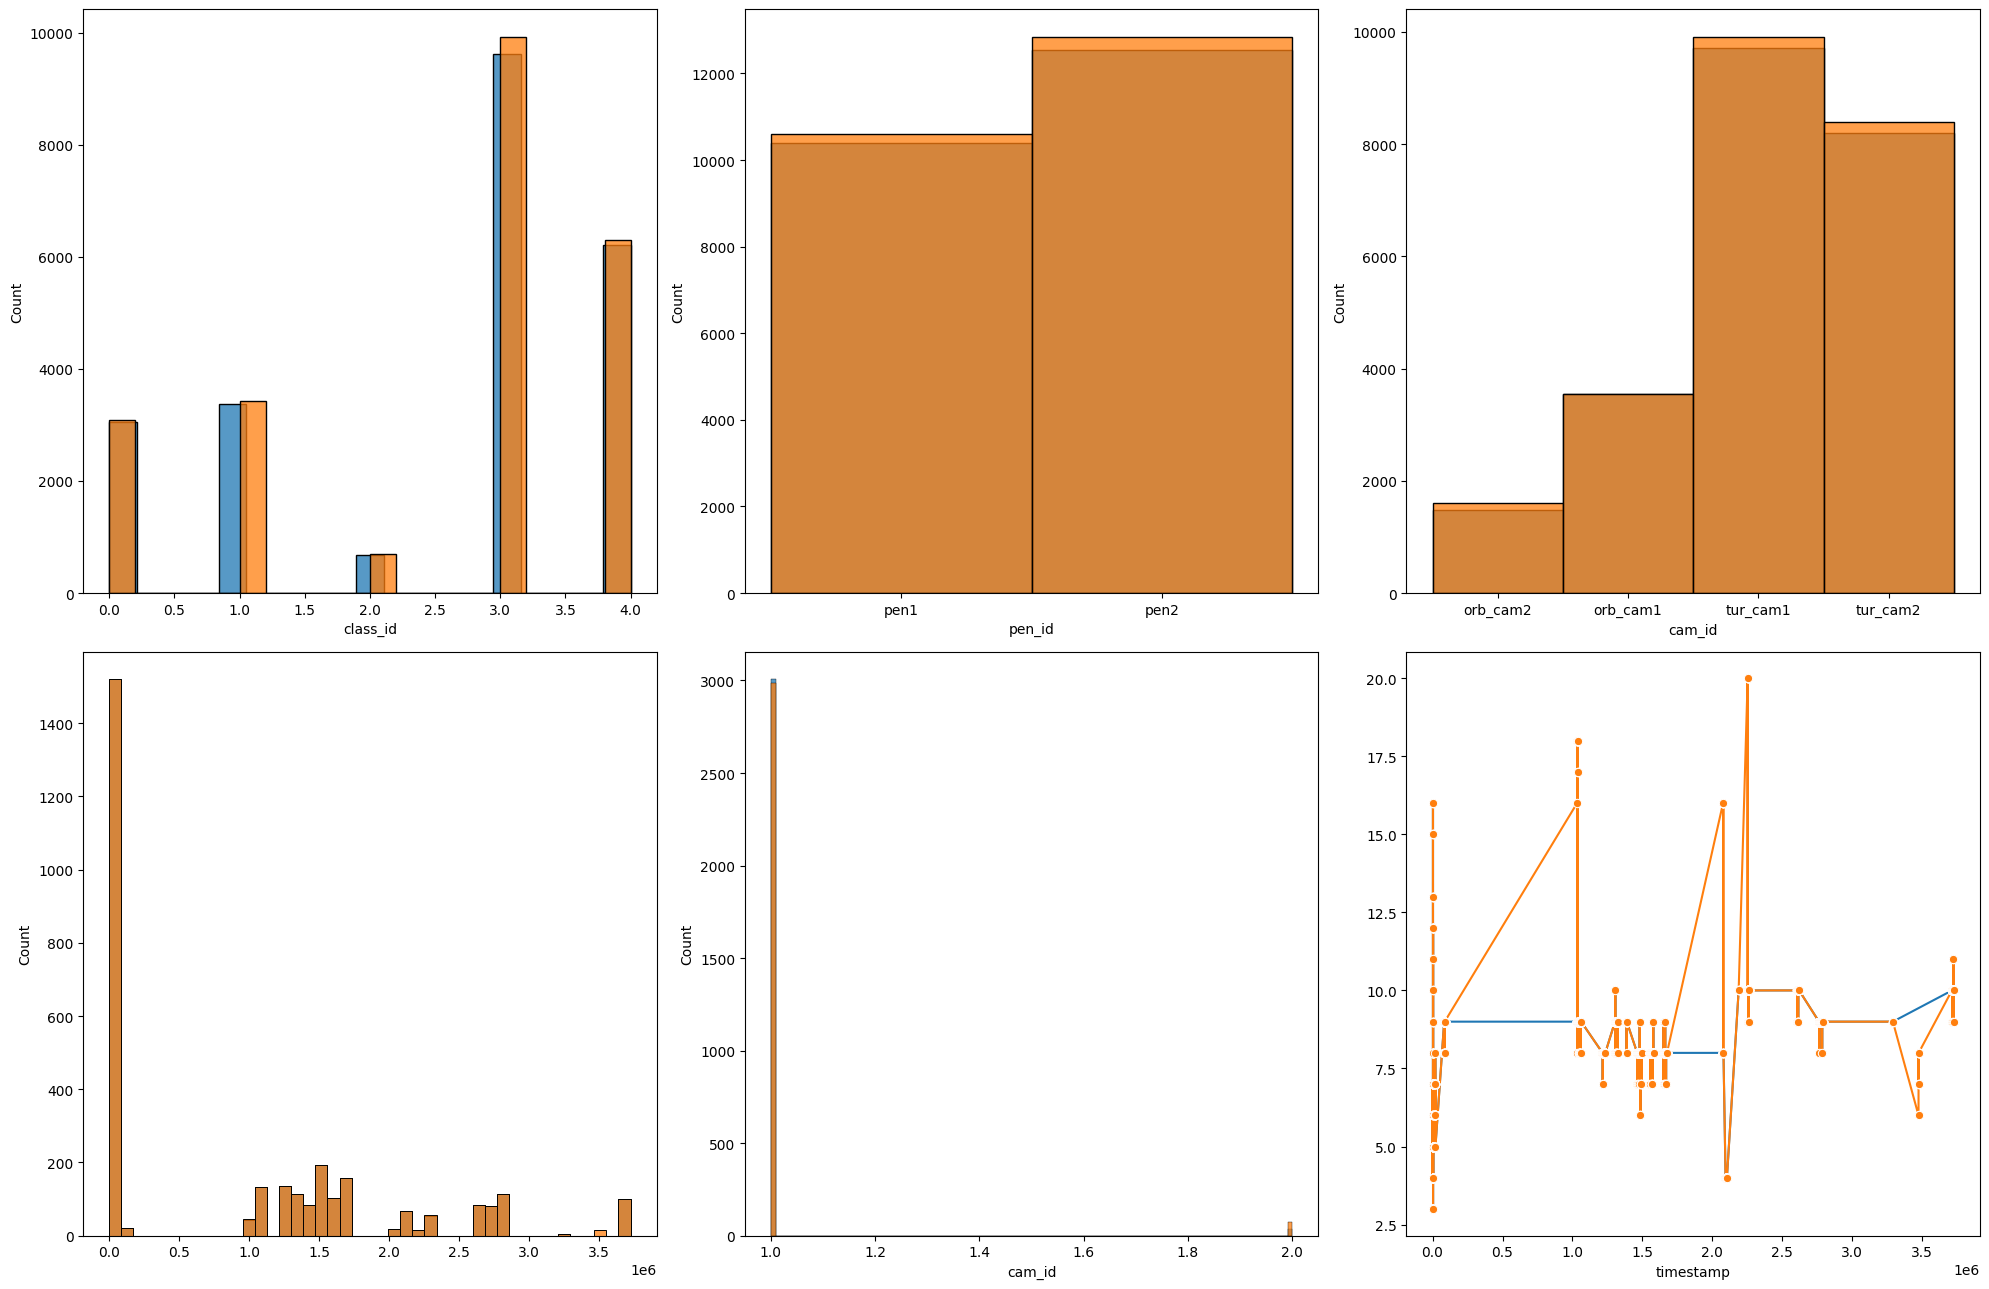

In [ ]:
fig, axs = plt.subplots(2, 3, figsize=(20, 13))

for label_df in train_label_dfs:
    # Number of labels per class, pen, and camera
    sns.histplot(label_df, x='class_id', ax=axs[0][0])

    sns.histplot(label_df, x='pen_id', ax=axs[0][1])
    sns.histplot(label_df, x='cam_id', ax=axs[0][2])

    # Shows the distribution of images over time.
    sns.histplot((pd.Series(label_df["timestamp"].unique()) - min_timestamp).dt.total_seconds(), 
                ax=axs[1][0],
                binwidth=24*3600) # 1 day in seconds

    # Number of unique cameras per timestamp
    sns.histplot(label_df.groupby('timestamp')['cam_id'].nunique(), ax=axs[1][1])

    # Number of unique labels (animal bboxes) per timestamp across cameras - there are roughly 5-10 animals in an image, and where the cameras are synchronized, we should see double or triple the number of labels at the same timestamp.
    grouped = label_df.groupby('timestamp')['cam_id'].count()
    x_vals = pd.Series(grouped.index - min_timestamp).dt.total_seconds()
    y_vals = grouped.values
    
    sns.lineplot(x=x_vals, y=y_vals, ax=axs[1][2], marker='o')

plt.tight_layout()
plt.show()

## Test dataset

In [10]:
preprocess_labels(test_label_df)
test_label_df.head(10)

,row_id,image_id,width,height,bbox,pen_id,cam_id,date_str,time_str,timestamp
7069,test_pen2_tur_cam2_20250920_174621_0000,pen2_tur_cam2_20250920_174621.jpg,1280,720,"[276.5,1.5,443.0,198.0]",pen2,tur_cam2,20250920,174621,2025-09-20 17:46:21
7071,test_pen2_tur_cam2_20250920_174621_0002,pen2_tur_cam2_20250920_174621.jpg,1280,720,"[266.0,295.5,251.0,371.0]",pen2,tur_cam2,20250920,174621,2025-09-20 17:46:21
7072,test_pen2_tur_cam2_20250920_174621_0003,pen2_tur_cam2_20250920_174621.jpg,1280,720,"[288.5,434.0,275.0,286.0]",pen2,tur_cam2,20250920,174621,2025-09-20 17:46:21
7073,test_pen2_tur_cam2_20250920_174621_0004,pen2_tur_cam2_20250920_174621.jpg,1280,720,"[726.5,388.5,208.0,155.0]",pen2,tur_cam2,20250920,174621,2025-09-20 17:46:21
7074,test_pen2_tur_cam2_20250920_174621_0005,pen2_tur_cam2_20250920_174621.jpg,1280,720,"[202.5,109.0,408.0,167.0]",pen2,tur_cam2,20250920,174621,2025-09-20 17:46:21
7075,test_pen2_tur_cam2_20250920_174621_0006,pen2_tur_cam2_20250920_174621.jpg,1280,720,"[895.0,81.0,180.0,171.0]",pen2,tur_cam2,20250920,174621,2025-09-20 17:46:21
7076,test_pen2_tur_cam2_20250920_174621_0007,pen2_tur_cam2_20250920_174621.jpg,1280,720,"[1044.5,299.0,98.0,196.0]",pen2,tur_cam2,20250920,174621,2025-09-20 17:46:21
7077,test_pen2_tur_cam2_20250920_174621_0008,pen2_tur_cam2_20250920_174621.jpg,1280,720,"[920.5,419.0,148.0,118.0]",pen2,tur_cam2,20250920,174621,2025-09-20 17:46:21
7078,test_pen2_tur_cam2_20250920_174621_0009,pen2_tur_cam2_20250920_174621.jpg,1280,720,"[1044.0,127.5,65.0,186.0]",pen2,tur_cam2,20250920,174621,2025-09-20 17:46:21
7070,test_pen2_tur_cam2_20250920_174621_0001,pen2_tur_cam2_20250920_174621.jpg,1280,720,"[486.0,355.5,251.0,327.0]",pen2,tur_cam2,20250920,174621,2025-09-20 17:46:21


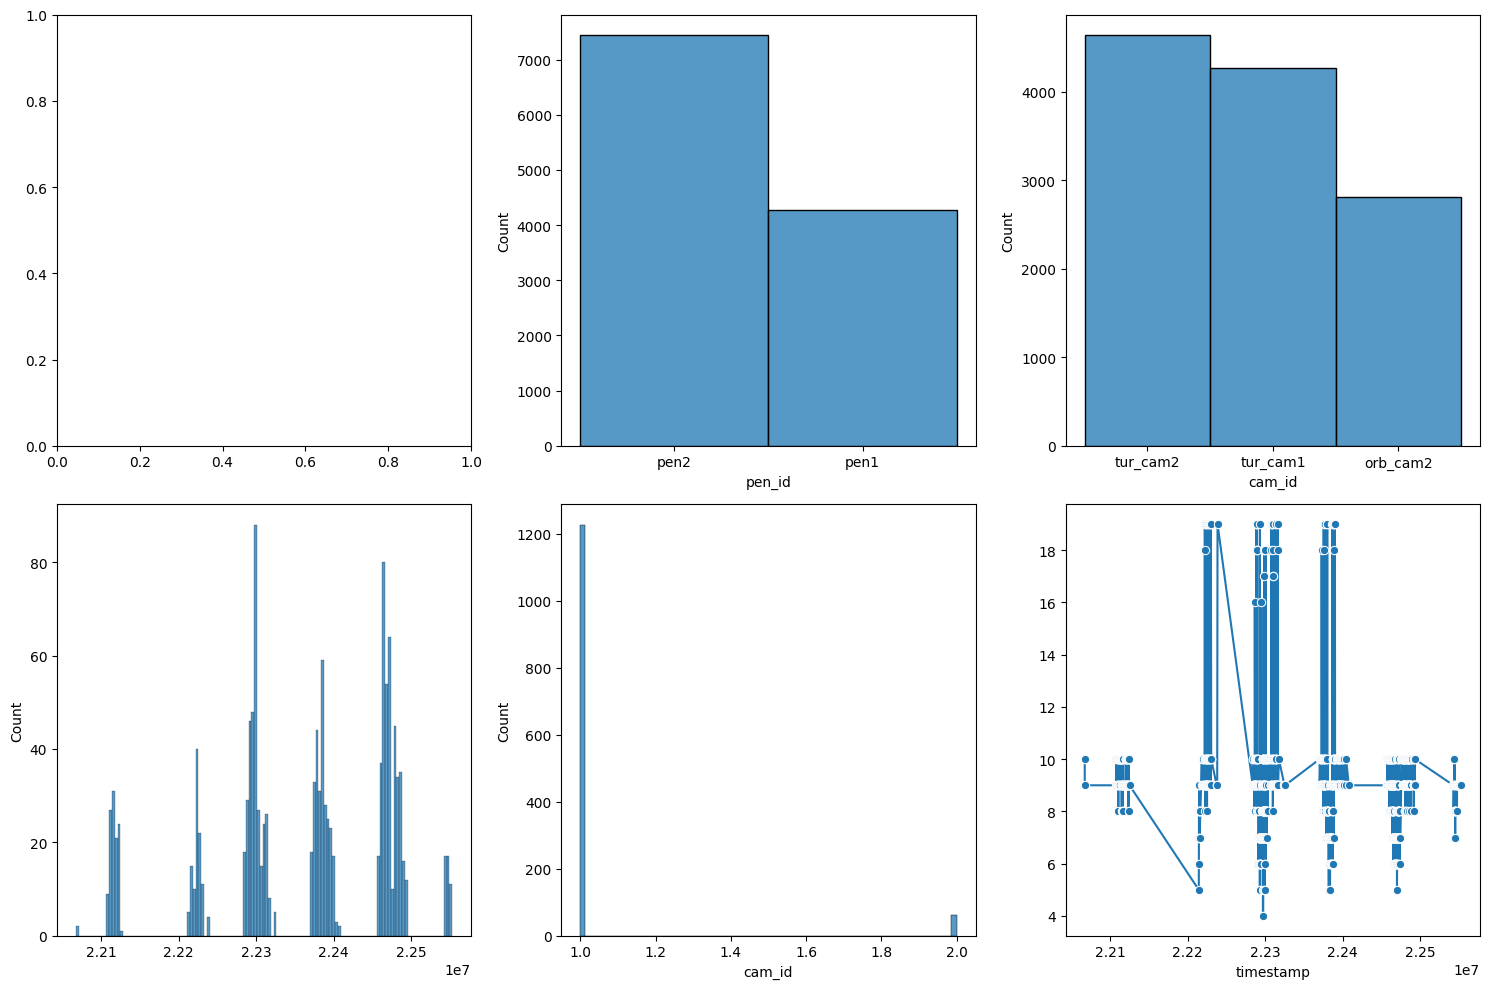

In [11]:
fig, axs = plt.subplots(2, 3, figsize=(15, 10))

# sns.histplot(label_df, x='class_id', ax=axs[0][0])

sns.histplot(test_label_df, x='pen_id', ax=axs[0][1])
sns.histplot(test_label_df, x='cam_id', ax=axs[0][2])

# Shows the distribution of images over time.
sns.histplot((pd.Series(test_label_df["timestamp"].unique()) - min_timestamp).dt.total_seconds(), 
            ax=axs[1][0],
            binwidth=3600) # 12 hours in seconds

# Number of unique cameras per timestamp
sns.histplot(test_label_df.groupby('timestamp')["cam_id"].nunique(), ax=axs[1][1])

grouped = test_label_df.groupby('timestamp')['cam_id'].count()
x_vals = pd.Series(grouped.index - min_timestamp).dt.total_seconds()
y_vals = grouped.values

sns.lineplot(x=x_vals, y=y_vals, ax=axs[1][2], marker='o')

plt.tight_layout()
plt.show()

## Temporal relationship between training and test data

<Axes: xlabel='timestamp', ylabel='Count'>

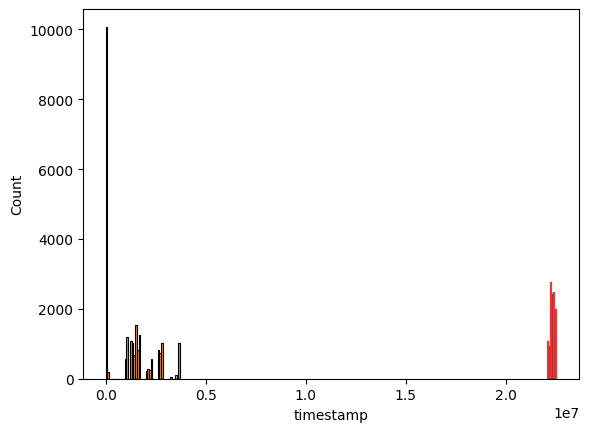

In [12]:
plt.figure()

for label_df in train_label_dfs:
    sns.histplot((label_df["timestamp"] - min_timestamp).dt.total_seconds(),
                binwidth=24*3600) # 1 day in seconds
sns.histplot((test_label_df["timestamp"] - min_timestamp).dt.total_seconds(),
             color='red', 
            binwidth=24*3600) # 1 day in seconds

Percent of timestamp differences less than or equal to 600 seconds between consecutive images from tur_cam1:
train0: 99.26%
train1: 99.10%
test: 85.95%


<Axes: ylabel='Count'>

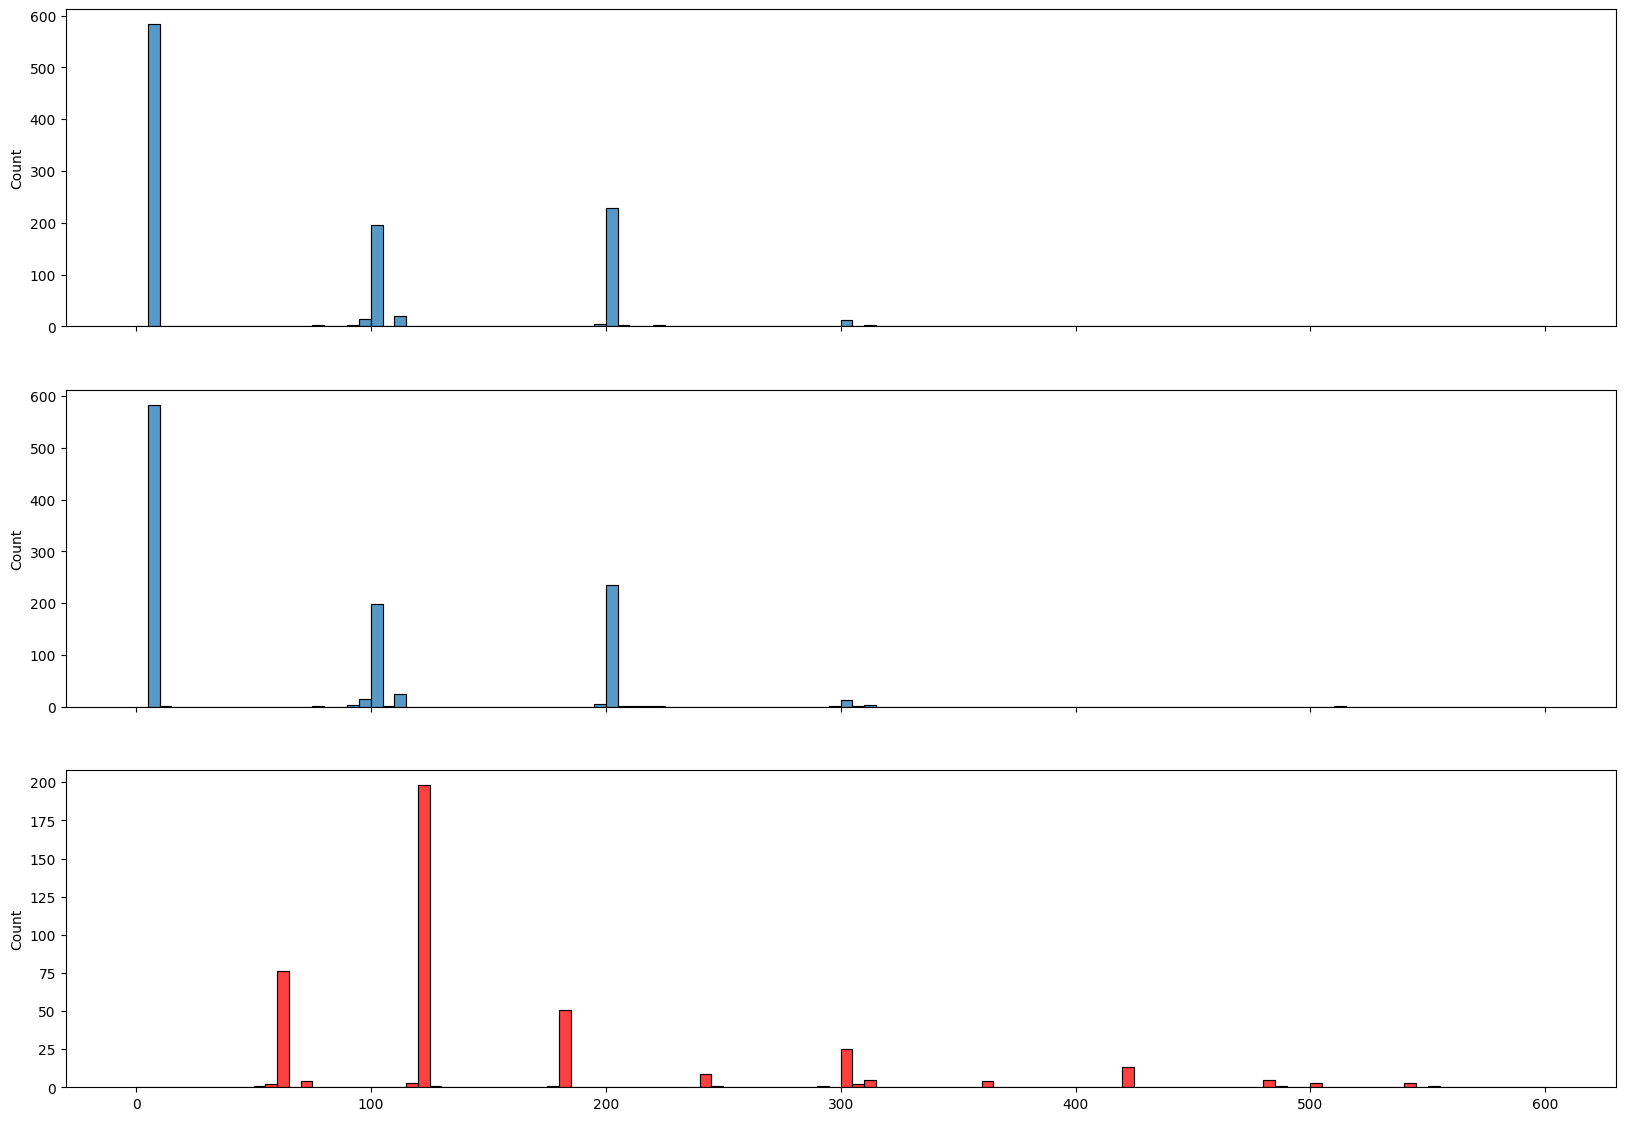

In [13]:
fig, axs = plt.subplots(3, 1, figsize=(20, 14), sharex=True)

max_timestamp = 600 # seconds
binwidth = 5 # seconds
cam_id = "tur_cam1"

print(f"Percent of timestamp differences less than or equal to {max_timestamp} seconds between consecutive images from {cam_id}:")

for idx, labels_df in enumerate(train_label_dfs):
    cam_labels_df = labels_df[labels_df["cam_id"] == cam_id]
    diffs = pd.Series(cam_labels_df["timestamp"].unique())
    diffs = diffs.diff().dt.total_seconds().dropna()
    percent = np.sum(diffs <= max_timestamp) / len(diffs)
    print(f"train{idx}: {percent:.2%}")
    sns.histplot(diffs, binwidth=binwidth, binrange=(0, max_timestamp), ax=axs[idx], legend=f"train{idx}")

cam_labels_df = test_label_df[test_label_df["cam_id"] == cam_id]
diffs = pd.Series(cam_labels_df["timestamp"].unique())
diffs = diffs.diff().dt.total_seconds().dropna()
percent = np.sum(diffs <= max_timestamp) / len(diffs)
print(f"test: {percent:.2%}")
sns.histplot(diffs, color='red', binwidth=binwidth, binrange=(0, max_timestamp), ax=axs[2], legend="test")